## Parameter Sweeping

Will be conducted on
- PD.frame_size, PD.hop_size, PD.freq_range
- ND.frame_size, ND.hop_size, ND.slope, ND.diff
- SE.ins, SE.del, SE.sub

And we choose the combination of parameters which minimizes the edit distance.

### First, understanding...
It would be good to understand what general parameters are effective. What dictates the frame and hop for PD and ND? What about general slopes and diffs which work? When do they work vs fail?

In [1]:
# autoreload when modules edited
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

from app_logic.midi.MidiData import MidiData
from app_logic.user.ds.UserData import UserData
from app_logic.user.ds.PitchData import PitchConfig
from app_logic.user.AudioRecorder import AudioRecorder
from app_logic.user.AudioPlayer import AudioPlayer

from algorithms.PitchDetector import PitchDetector
from algorithms.NoteDetector import NoteDetector
from algorithms.StringEditor import StringEditor
from algorithms.Config import Config

In [ ]:
# initialize user data with sample recording
pconfig = PitchConfig( # default values
    tuning=440,
    fmin=196,
    fmax=5000
)
pd, nd = PitchDetector(pconfig), NoteDetector()
us = UserData(pd, nd)
us.load_audio('../resources/recordings/bach_fugue_recording.mp3') # also detects pitches and notes on load

Starting pitch detection...
Processing frame 4482/4482
Done!
Starting note detection...
Note detection: Done!


### Accuracy check: Pitch Detection

Compare the detected pitches of audio to the MIDI file it was originally synthesized from.

In [70]:
# test pitch detection accuracy
import pretty_midi
import soundfile as sf

SF_PATH = "../resources/MuseScore_General.sf3"
INPUT_MIDI_PATH = "../resources/scores/fugue.mid"
OUTPUT_PATH = "../resources/scores/midi-to-audio/fugue.wav"

config = {
    'sr': 44100,    # sample rate
    'w1': 1024 * 8,  # frame size
    'h1': 128,       # hop size
    'fmin': 196.0,
    'fmax': 3000.0,
    'tuning': 440.0,
    'unv_thresh': 0.8, # if unvoiced_prob > unv_thresh, consider the frame unvoiced

    # --- NOTE DETECTION PARAMETERS ---
    'w2': 30, # frame size
    'h2': 27, # hop size
    'pitch_thresh': 0.75,
    'slope_thresh': 1.5,
    'unv_ratio': 0.5, # proportion of unvoiced pitches in a window to consider the window unvoiced

    # --- STRING EDIT PARAMETERS ---
    'ins_cost': 1.5,
    'del_cost': 2,
    'sub_cost': 1,
    'tolerance': 1,
    # tiger-mom parameter
    'tiger_level': 1
}
config = Config(**config)

# synthesize midi to audio
mid = pretty_midi.PrettyMIDI(INPUT_MIDI_PATH)
audio = mid.fluidsynth(synthesizer=SF_PATH, fs=44100)
sf.write(OUTPUT_PATH, audio, 44100)

# load and detect pitches
pd, nd = PitchDetector(config), NoteDetector(config)
us1 = UserData(pd, nd)
us1.load_audio(OUTPUT_PATH)

Starting pitch detection...
Processing frame 4544/4544
Done!
Starting note detection...
Note detection: Done!


In [3]:
# test pitch detection accuracy
ANNOT_DIR = "../resources/mdb-stem-synth/annotation_stems/AClassicEducation_NightOwl_STEM_01.RESYN.csv"
AUDIO_DIR = "../resources/mdb-stem-synth/audio_stems/AClassicEducation_NightOwl_STEM_01.RESYN.wav"

config = {
    'sr': 44100,    # sample rate
    'w1': 1024 * 8,  # frame size
    'h1': 128,       # hop size
    'fmin': 196.0,
    'fmax': 3000.0,
    'tuning': 440.0,
    'unv_thresh': 0.8, # if unvoiced_prob > unv_thresh, consider the frame unvoiced

    # --- NOTE DETECTION PARAMETERS ---
    'w2': 30, # frame size
    'h2': 27, # hop size
    'pitch_thresh': 0.75,
    'slope_thresh': 1.5,
    'unv_ratio': 0.5, # proportion of unvoiced pitches in a window to consider the window unvoiced

    # --- STRING EDIT PARAMETERS ---
    'ins_cost': 1.5,
    'del_cost': 2,
    'sub_cost': 1,
    'tolerance': 1,
    # tiger-mom parameter
    'tiger_level': 1
}
config = Config(**config)

# load and detect pitches
pd, nd = PitchDetector(config), NoteDetector(config)
us1 = UserData(pd, nd)
us1.load_audio(AUDIO_DIR)

Starting pitch detection...
Processing frame 59003/59003
Done!
Starting note detection...
Note detection: Done!


In [65]:
import pandas as pd

rows = []
mid1 = MidiData(INPUT_MIDI_PATH)

for p in us1.pitch_data.data:
    t = p.time
    if p.unvoiced_prob > config.unv_thresh:
        continue # skip unvoiced frames
    
    p_u = p.candidates[0][0] # most probable candidate
    
    midi_note = mid1.note_data.read_note(start_time=t)
    p_m = midi_note.midi_num[0]

    err = abs(p_u - p_m)
    correct = err <= 0.5

    rows.append({
        "time": t,
        "detected_pitch": p_u,
        "true_pitch": p_m,
        "error": err,
        "correct": correct,
    })

# aggregate statistics
df = pd.DataFrame(rows)

total_pitches   = len(df)
correct_pitches = df["correct"].sum()
median_error      = df["error"].median()
accuracy        = correct_pitches / total_pitches * 100

print(f"Total pitches: {total_pitches}")
print(f"Correct pitches: {correct_pitches}")
print(f"Median Error: {median_error}")
print(f"Accuracy: {accuracy}%")


Loading score file: ../resources/scores/fugue.mid (ext: .mid)
Handling MIDI file...
Total pitches: 3442
Correct pitches: 2426
Median Error: 0.06945197345606147
Accuracy: 70.4822777454968%


### Pitch Detection: Plots
Accuracy, errors, etc.

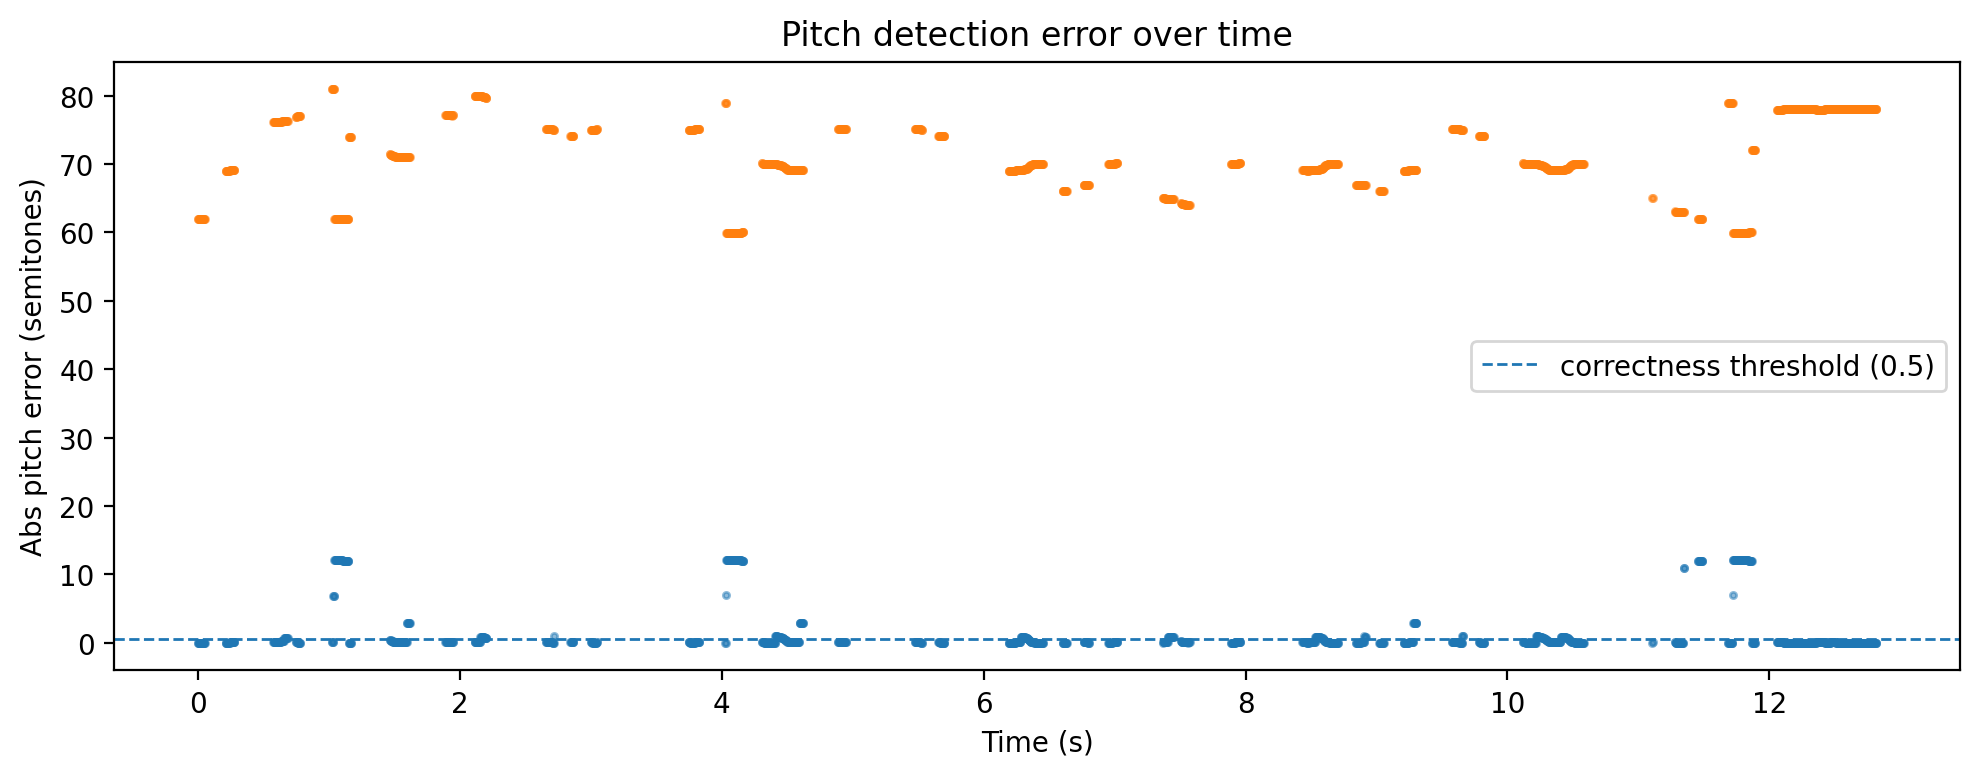

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# scatter of absolute error over time
plt.scatter(df["time"], df["error"], s=5, alpha=0.5)
plt.scatter(df["time"], df["detected_pitch"], s=5, alpha=0.5)
plt.axhline(0.5, linestyle="--", linewidth=1, label="correctness threshold (0.5)")
plt.xlabel("Time (s)")
plt.ylabel("Abs pitch error (semitones)")
plt.title("Pitch detection error over time")
plt.legend()
plt.tight_layout()
plt.show()

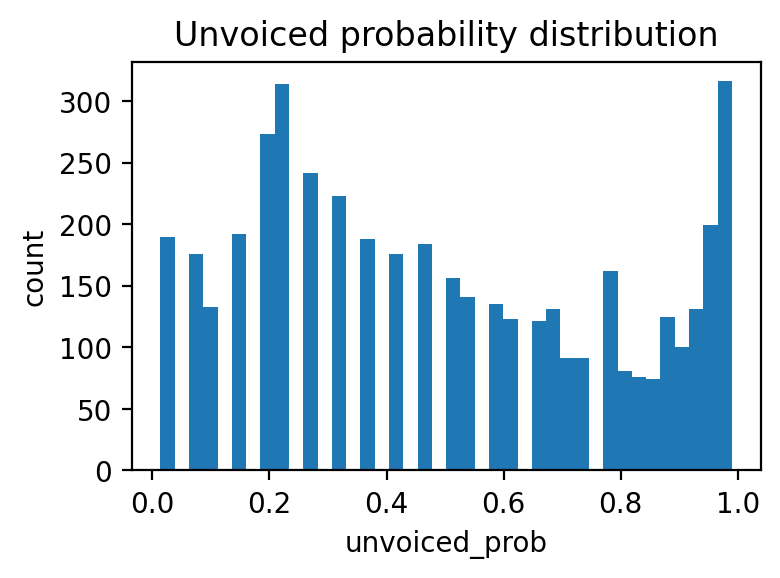

In [57]:
unvoiced_probs = [p.unvoiced_prob for p in us1.pitch_data.data]

plt.figure(figsize=(4, 3))
plt.hist(unvoiced_probs, bins=40)
plt.xlabel("unvoiced_prob")
plt.ylabel("count")
plt.title("Unvoiced probability distribution")
plt.tight_layout()
plt.show()

In [21]:
from IPython.display import Audio

Audio(data=us1.audio_data.data, rate=us1.audio_data.sr)

In [66]:
%gui qt

import sys
from PyQt6.QtWidgets import QApplication
from PyQt6.QtCore import QCoreApplication

sys.path.append('../')
from ui.ScorePlot import RunScorePlot

if __name__ == '__main__':
    if not QCoreApplication.instance():
        app = QApplication(sys.argv)
    else:
        app = QCoreApplication.instance()

    vis = RunScorePlot(user_data=us1, midi_data=mid1, app=app)

Loading MIDI data into ScorePlot...
Loading UserData into ScorePlot...


In [ ]:
from dataclasses import dataclass

@dataclass
class Config:
    # --- PITCH DETECTION PARAMETERS ---
    w1: int = 1024 * 6  # frame size
    h1: int = 128       # hop size
    fmin: float = 196.0
    fmax: float = 5000.0
    tuning: float = 440.0
    unv_thresh: float = 0.3

    # --- NOTE DETECTION PARAMETERS ---
    w2: int = 30 # frame size
    h2: int = 27 # hop size
    pitch_thresh: float = 0.5
    slope_thresh: float = 1.5

    # --- STRING EDIT PARAMETERS ---
    ins_cost: float = 1.5
    del_cost: float = 2
    sub_cost: float = 1
    tolerance: float = 1                                              

    # tiger-mom parameter
    tiger_level: int = 1
